In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
df = pd.read_csv("../data/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [39]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 768
Columns: 9


In [40]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [42]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [43]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [46]:
df["Outcome"].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In [47]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[zero_columns] = df[zero_columns].replace(0, np.nan)

In [48]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [49]:
for col in zero_columns:
    df[col] = df[col].fillna(df[col].median())

In [50]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [51]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [52]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


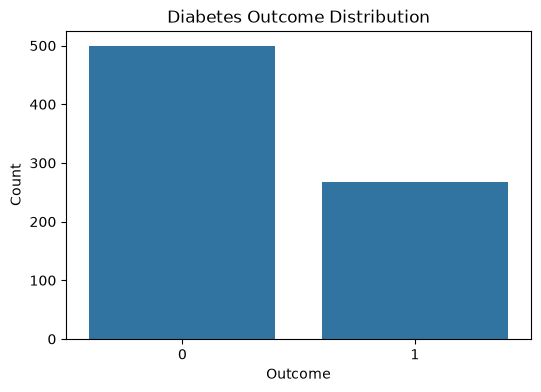

In [53]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Outcome")

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.show()

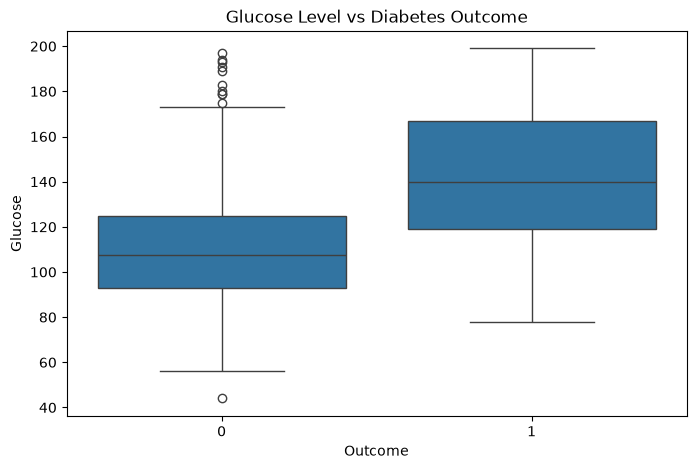

In [54]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Outcome", y="Glucose")

plt.title("Glucose Level vs Diabetes Outcome")

plt.show()

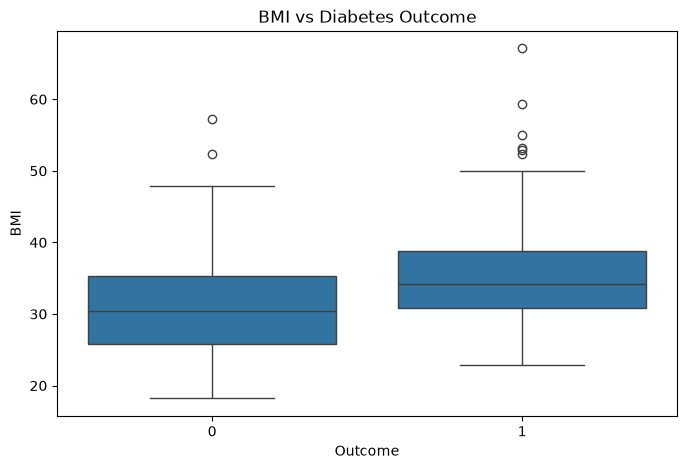

In [55]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Outcome", y="BMI")

plt.title("BMI vs Diabetes Outcome")

plt.show()

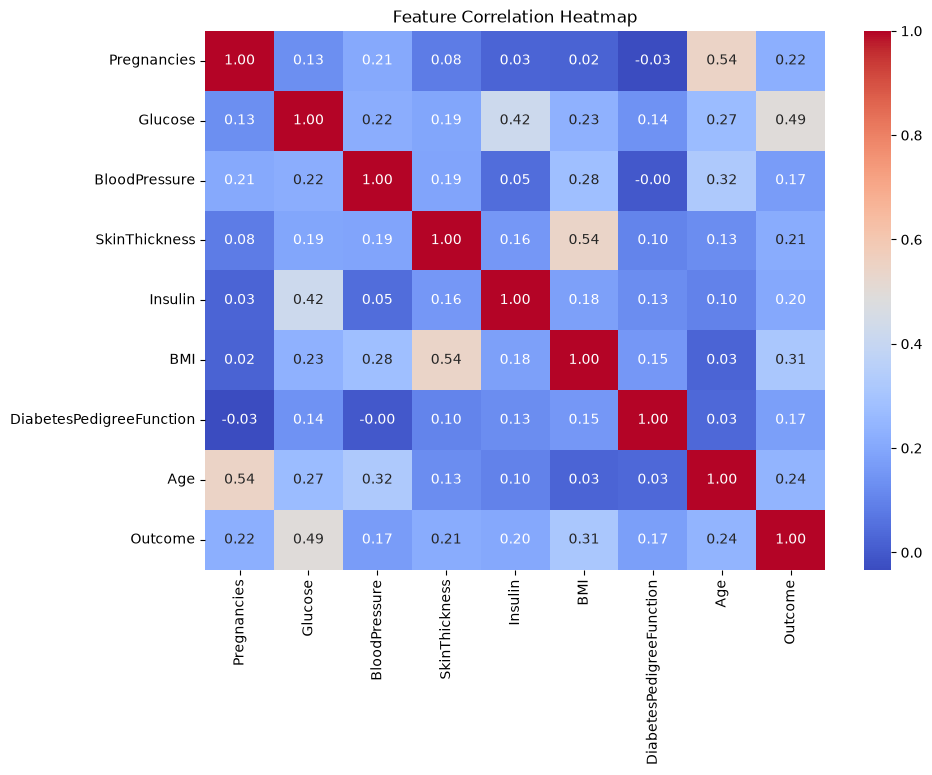

In [56]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [57]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (768, 8)
Target: (768,)


In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Outcome
0    400
1    214
Name: count, dtype: int64

After SMOTE:
Outcome
0    400
1    400
Name: count, dtype: int64


In [61]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

lr_model.fit(
    X_train_smote,
    y_train_smote
)

lr_pred = lr_model.predict(X_test_scaled)

In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

Accuracy : 0.7142857142857143
Precision: 0.5806451612903226
Recall   : 0.6666666666666666
F1 Score : 0.6206896551724138


In [63]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.80      0.74      0.77       100
           1       0.58      0.67      0.62        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.70       154
weighted avg       0.73      0.71      0.72       154



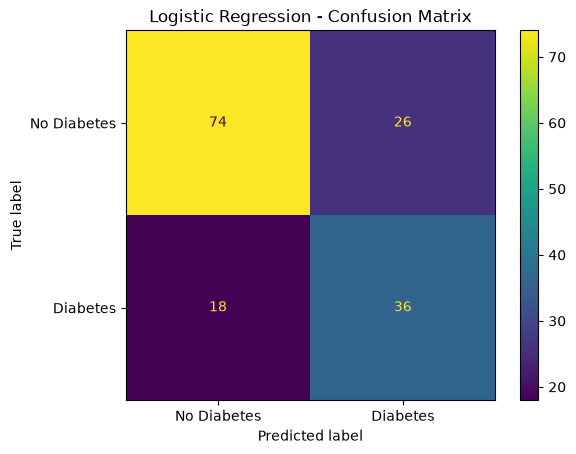

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [65]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

rf_pred = rf_model.predict(X_test)

c:\Users\PC\OneDrive\Desktop\Healthcare_Disease_Prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [66]:
from imblearn.over_sampling import SMOTE

smote_rf = SMOTE(random_state=42)

X_train_rf, y_train_rf = smote_rf.fit_resample(
    X_train,
    y_train
)

In [67]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_rf, y_train_rf)

rf_pred = rf_model.predict(X_test)

In [68]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.7337662337662337
Precision: 0.6101694915254238
Recall   : 0.6666666666666666
F1 Score : 0.6371681415929203


In [69]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.81      0.77      0.79       100
           1       0.61      0.67      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.74       154



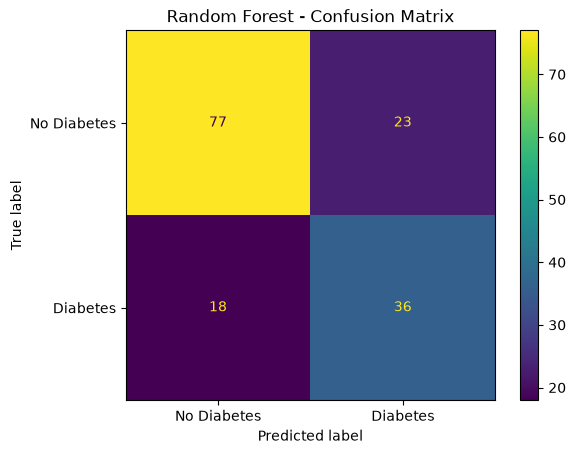

In [70]:
cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [71]:
from sklearn.svm import SVC

svm_model = SVC(
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_smote,
    y_train_smote
)

svm_pred = svm_model.predict(X_test_scaled)

c:\Users\PC\OneDrive\Desktop\Healthcare_Disease_Prediction\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [72]:
print("Accuracy :", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall   :", recall_score(y_test, svm_pred))
print("F1 Score :", f1_score(y_test, svm_pred))

Accuracy : 0.7272727272727273
Precision: 0.5967741935483871
Recall   : 0.6851851851851852
F1 Score : 0.6379310344827587


In [73]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, svm_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.714286,0.580645,0.666667,0.620690
1,Random Forest,0.733766,0.610169,0.666667,0.637168
2,SVM,0.727273,0.596774,0.685185,0.637931


In [74]:
import sys
import xgboost

print("Python:", sys.executable)
print("XGBoost:", xgboost.__version__)

Python: c:\Users\PC\OneDrive\Desktop\Healthcare_Disease_Prediction\.venv\Scripts\python.exe
XGBoost: 3.4.1


In [75]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_pred = xgb_model.predict(X_test_scaled)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Accuracy : 0.7597402597402597
Precision: 0.6307692307692307
Recall   : 0.7592592592592593
F1 Score : 0.6890756302521008

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       100
           1       0.63      0.76      0.69        54

    accuracy                           0.76       154
   macro avg       0.74      0.76      0.75       154
weighted avg       0.78      0.76      0.76       154



In [77]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, svm_pred),
        precision_score(y_test, xgb_pred)
    ],
    
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_pred),
        recall_score(y_test, xgb_pred)
    ],
    
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, xgb_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.714286,0.580645,0.666667,0.620690
1,Random Forest,0.733766,0.610169,0.666667,0.637168
2,SVM,0.727273,0.596774,0.685185,0.637931
3,XGBoost,0.759740,0.630769,0.759259,0.689076


In [78]:
best_model = results.loc[
    results["F1 Score"].idxmax()
]

print("Best Model:", best_model["Model"])
print("F1 Score:", best_model["F1 Score"])

Best Model: XGBoost
F1 Score: 0.6890756302521008


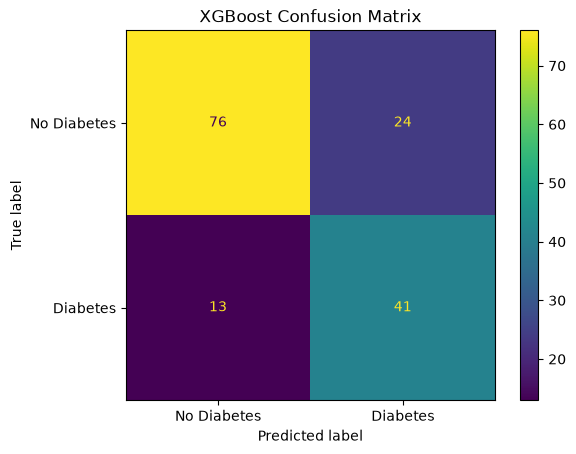

In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, xgb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

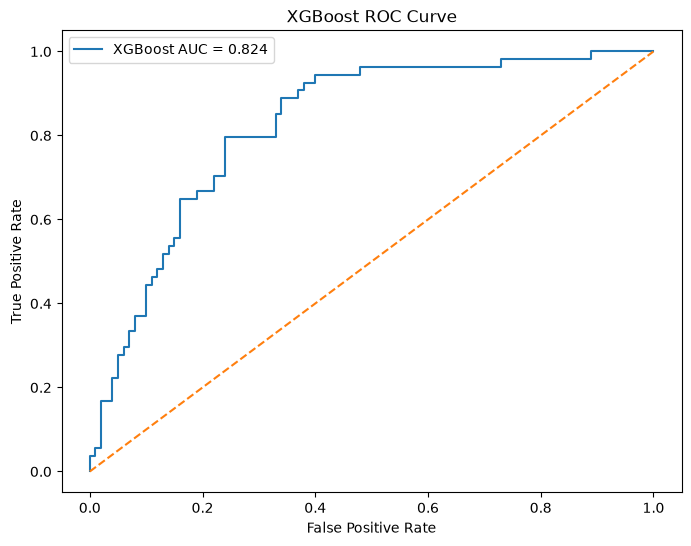

AUC Score: 0.8242592592592592


In [80]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, xgb_prob)

auc_score = roc_auc_score(y_test, xgb_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"XGBoost AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", auc_score)

In [81]:
import joblib

joblib.dump(xgb_model, "../models/xgboost_diabetes_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("Models saved successfully!")

Models saved successfully!


In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# XGBoost predictions
y_pred = xgb_model.predict(X_test_scaled)

# Probability for ROC-AUC
y_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("===== XGBoost Model Evaluation =====")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

===== XGBoost Model Evaluation =====
Accuracy  : 0.7597
Precision : 0.6308
Recall    : 0.7593
F1 Score  : 0.6891
ROC-AUC   : 0.8243

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       100
           1       0.63      0.76      0.69        54

    accuracy                           0.76       154
   macro avg       0.74      0.76      0.75       154
weighted avg       0.78      0.76      0.76       154


Confusion Matrix:
[[76 24]
 [13 41]]


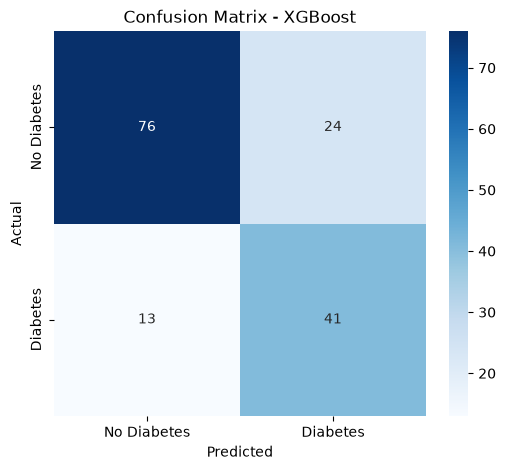

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric="logloss"
    )
}

results = []

for name, model in models.items():

    model.fit(X_train_smote, y_train_smote)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.714286,0.580645,0.666667,0.620690
1,Random Forest,0.753247,0.629032,0.722222,0.672414
2,XGBoost,0.759740,0.630769,0.759259,0.689076


In [85]:
best_model_name = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

print("🏆 Best Model:", best_model_name)

🏆 Best Model: XGBoost


In [86]:
import joblib

best_model = models[best_model_name]

joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

print("✅ Best model saved successfully!")

✅ Best model saved successfully!


In [87]:
import joblib
import os

# Best model
best_model = models[best_model_name]

# Models folder path
models_path = "../models"

# Save best model
joblib.dump(
    best_model,
    os.path.join(models_path, "best_model.pkl")
)

# Save scaler
joblib.dump(
    scaler,
    os.path.join(models_path, "scaler.pkl")
)

print("✅ Best model saved successfully!")
print("✅ Scaler saved successfully!")

✅ Best model saved successfully!
✅ Scaler saved successfully!


In [88]:
import os

print("Best Model exists:",
      os.path.exists("../models/best_model.pkl"))

print("Scaler exists:",
      os.path.exists("../models/scaler.pkl"))

Best Model exists: True
Scaler exists: True


In [89]:
results_df.to_csv(
    "../models/model_comparison.csv",
    index=False
)

print("✅ Model comparison saved!")

✅ Model comparison saved!


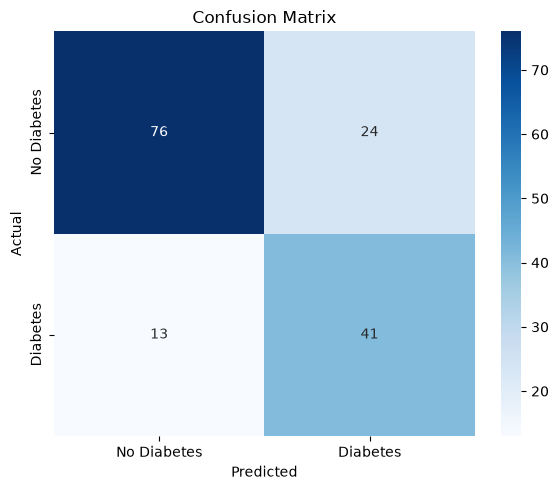

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Best model prediction
y_pred_best = best_model.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "../models/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

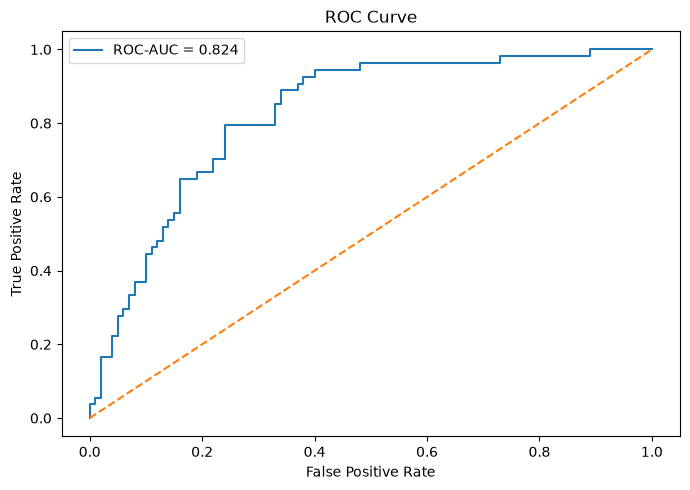

ROC-AUC: 0.8242592592592592


In [91]:
from sklearn.metrics import roc_curve, roc_auc_score

# Prediction probability
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_best
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_best
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.tight_layout()

plt.savefig(
    "../models/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ROC-AUC:", roc_auc)